# Cement NPV summary

Run the cement Monte Carlo NPV distribution, deterministic NPV, and Monte Carlo ranking summaries. The distribution table includes the number and share of simulations with non-negative NPV (NPV >= 0) and the number with negative NPV. This notebook displays figures inline only; it does not save figures or CSV files.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_deterministic import calculate_deterministic_cement_results
from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)
from cement.cement_npv_summary_figures import (
    CEMENT_FINANCIAL_METRIC_OPTIONS,
    CEMENT_TECHNOLOGY_LABELS,
    calculate_cement_npv_rankings_from_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_average_rank_bars, plot_financial_metric_technology_bars


## Settings

In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE
TECHNOLOGIES = tuple(CEMENT_TECHNOLOGY_LABELS)
FINANCIAL_METRIC = "LNM"  # "NPV" or "LNM"

if FINANCIAL_METRIC not in CEMENT_FINANCIAL_METRIC_OPTIONS:
    raise ValueError(f"Unknown FINANCIAL_METRIC: {FINANCIAL_METRIC!r}")

METRIC_CONFIG = CEMENT_FINANCIAL_METRIC_OPTIONS[FINANCIAL_METRIC]
METRIC_COLUMN = str(METRIC_CONFIG["metric_column"])
METRIC_SCALE_FACTOR = float(METRIC_CONFIG["scale"])
METRIC_SUMMARY_COLUMN = str(METRIC_CONFIG["summary_column"])
METRIC_AXIS_LABEL = str(METRIC_CONFIG["axis_label"])
METRIC_RANKING_LABEL = str(METRIC_CONFIG["ranking_label"])

pd.options.display.float_format = "{:,.3f}".format


## Monte Carlo NPV distribution

,label,technology_type,levelized_net_margin_eur_per_t,median,p05,p95,non_negative_count,negative_count,non_negative_share
7,CCS,retrofit,46.858,48.222,15.990,73.066,99683,317,0.997
8,Process heat integration,retrofit,44.562,44.543,37.354,51.791,100000,0,1.000
6,Waste heat recovery,retrofit,44.142,44.226,37.926,50.014,100000,0,1.000
3,Clinker substitution,retrofit,44.010,43.992,36.397,51.679,100000,0,1.000
4,Alternative fuels,retrofit,43.901,43.898,35.713,52.114,100000,0,1.000
5,Efficiency improvement,retrofit,42.029,42.073,35.240,48.619,100000,0,1.000
0,BAU,absolute,40.839,40.827,34.016,47.688,100000,0,1.000
1,Electrification,absolute,-104.552,-106.913,-157.802,-43.549,5,99995,0.000
2,Electrolysis,absolute,-382.488,-373.016,-590.055,-202.212,0,100000,0.000


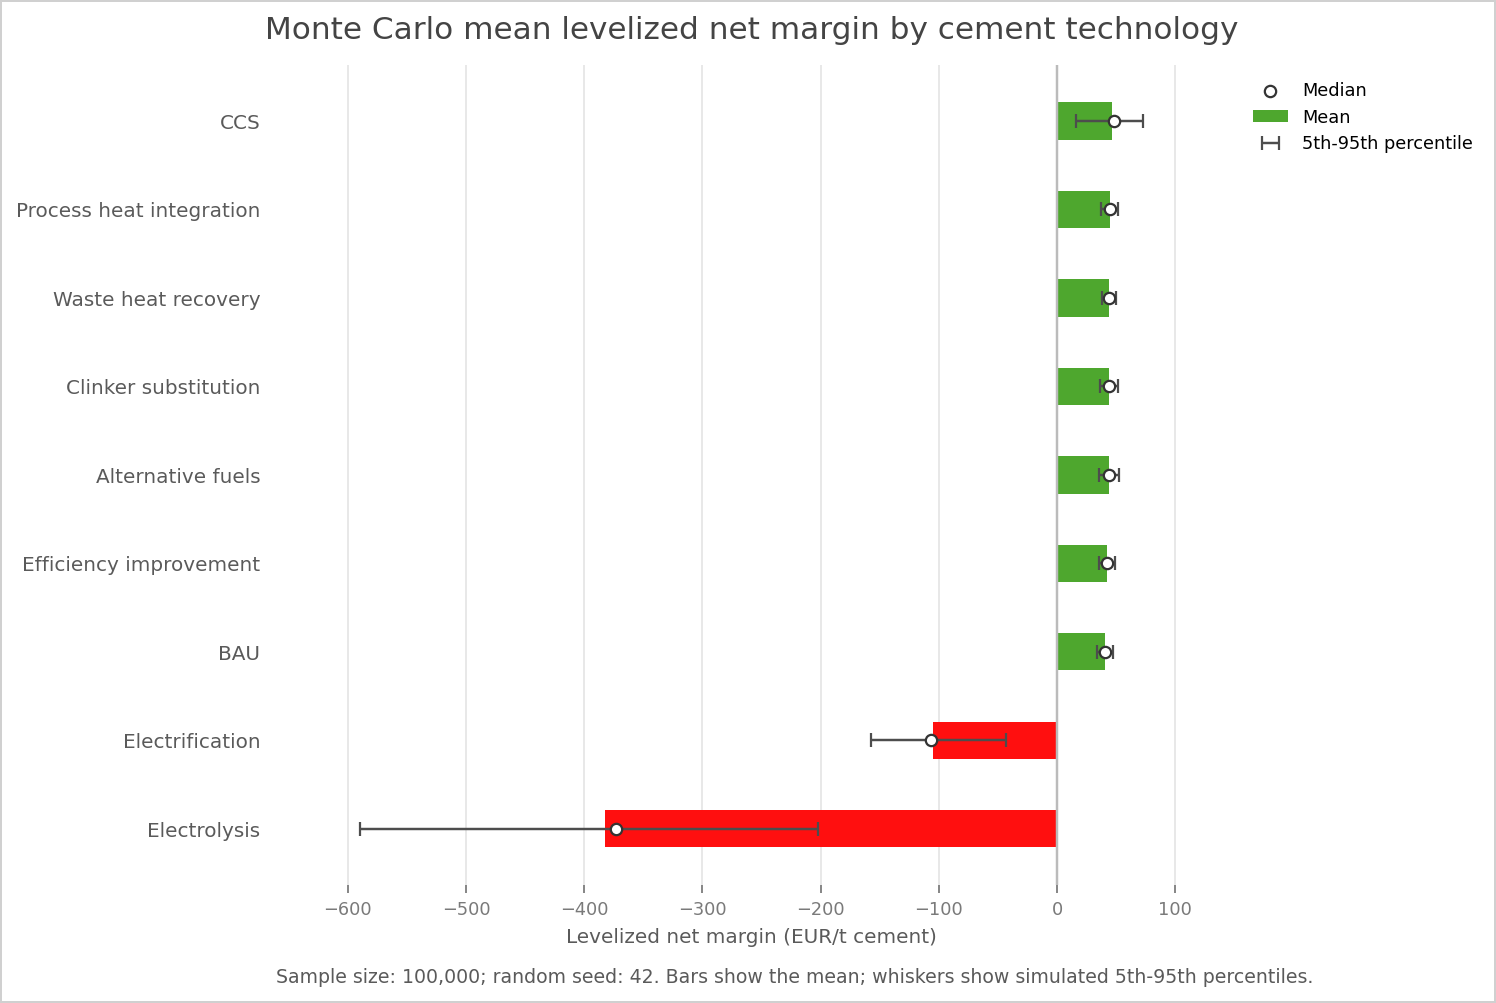

In [3]:
monte_carlo_results = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)

mc_summary_rows = []
for technology, results in monte_carlo_results.items():
    values = np.asarray(results[METRIC_COLUMN], dtype=float) / METRIC_SCALE_FACTOR
    mc_summary_rows.append(
        {
            "label": CEMENT_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            METRIC_SUMMARY_COLUMN: values.mean(),
            "median": np.median(values),
            "p05": np.percentile(values, 5),
            "p95": np.percentile(values, 95),
            **summarize_metric_signs(values),
        }
    )
mc_summary = pd.DataFrame(mc_summary_rows).sort_values(METRIC_SUMMARY_COLUMN, ascending=False)
mc_summary_by_label = mc_summary.set_index("label")

display(mc_summary)
plot_financial_metric_technology_bars(
    values=mc_summary_by_label[METRIC_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Monte Carlo mean {METRIC_RANKING_LABEL} by cement technology",
    median_values=mc_summary_by_label["median"].to_dict(),
    lower_values=mc_summary_by_label["p05"].to_dict(),
    upper_values=mc_summary_by_label["p95"].to_dict(),
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    x_axis_label=METRIC_AXIS_LABEL,
)
plt.show()


## Deterministic NPV

,label,technology_type,levelized_net_margin_eur_per_t
7,CCS,retrofit,49.604
8,Process heat integration,retrofit,47.861
6,Waste heat recovery,retrofit,47.380
4,Alternative fuels,retrofit,47.374
3,Clinker substitution,retrofit,47.126
5,Efficiency improvement,retrofit,45.436
0,BAU,absolute,44.428
1,Electrification,absolute,-101.925
2,Electrolysis,absolute,-376.607


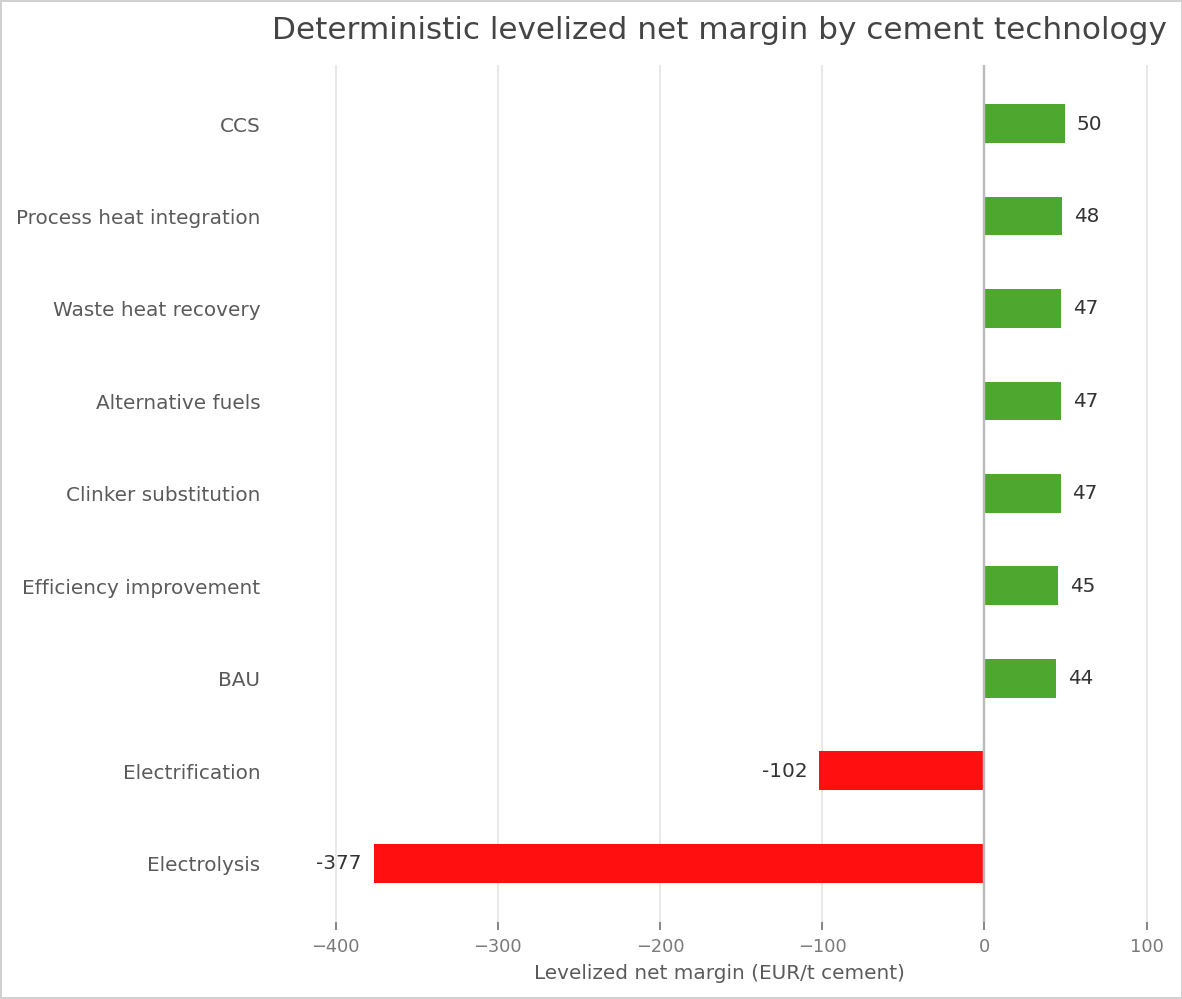

In [4]:
deterministic_results = calculate_deterministic_cement_results(technologies=TECHNOLOGIES)
det_summary_rows = []
for technology, results in deterministic_results.items():
    det_summary_rows.append(
        {
            "label": CEMENT_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            METRIC_SUMMARY_COLUMN: float(np.asarray(results[METRIC_COLUMN]).item()) / METRIC_SCALE_FACTOR,
        }
    )
det_summary = pd.DataFrame(det_summary_rows).sort_values(METRIC_SUMMARY_COLUMN, ascending=False)

display(det_summary)
plot_financial_metric_technology_bars(
    values=det_summary.set_index("label")[METRIC_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Deterministic {METRIC_RANKING_LABEL} by cement technology",
    x_axis_label=METRIC_AXIS_LABEL,
)
plt.show()


## Monte Carlo NPV ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,Process heat integration,2.992,0.128,0.661,100000
1,Waste heat recovery,3.229,0.088,0.582,100000
2,CCS,3.487,0.521,0.578,100000
3,Clinker substitution,3.515,0.118,0.535,100000
4,Alternative fuels,3.634,0.141,0.525,100000
5,Efficiency improvement,4.998,0.004,0.119,100000
6,BAU,6.145,0.000,0.002,100000
7,Electrification,8.000,0.000,0.000,100000
8,Electrolysis,9.000,0.000,0.000,100000


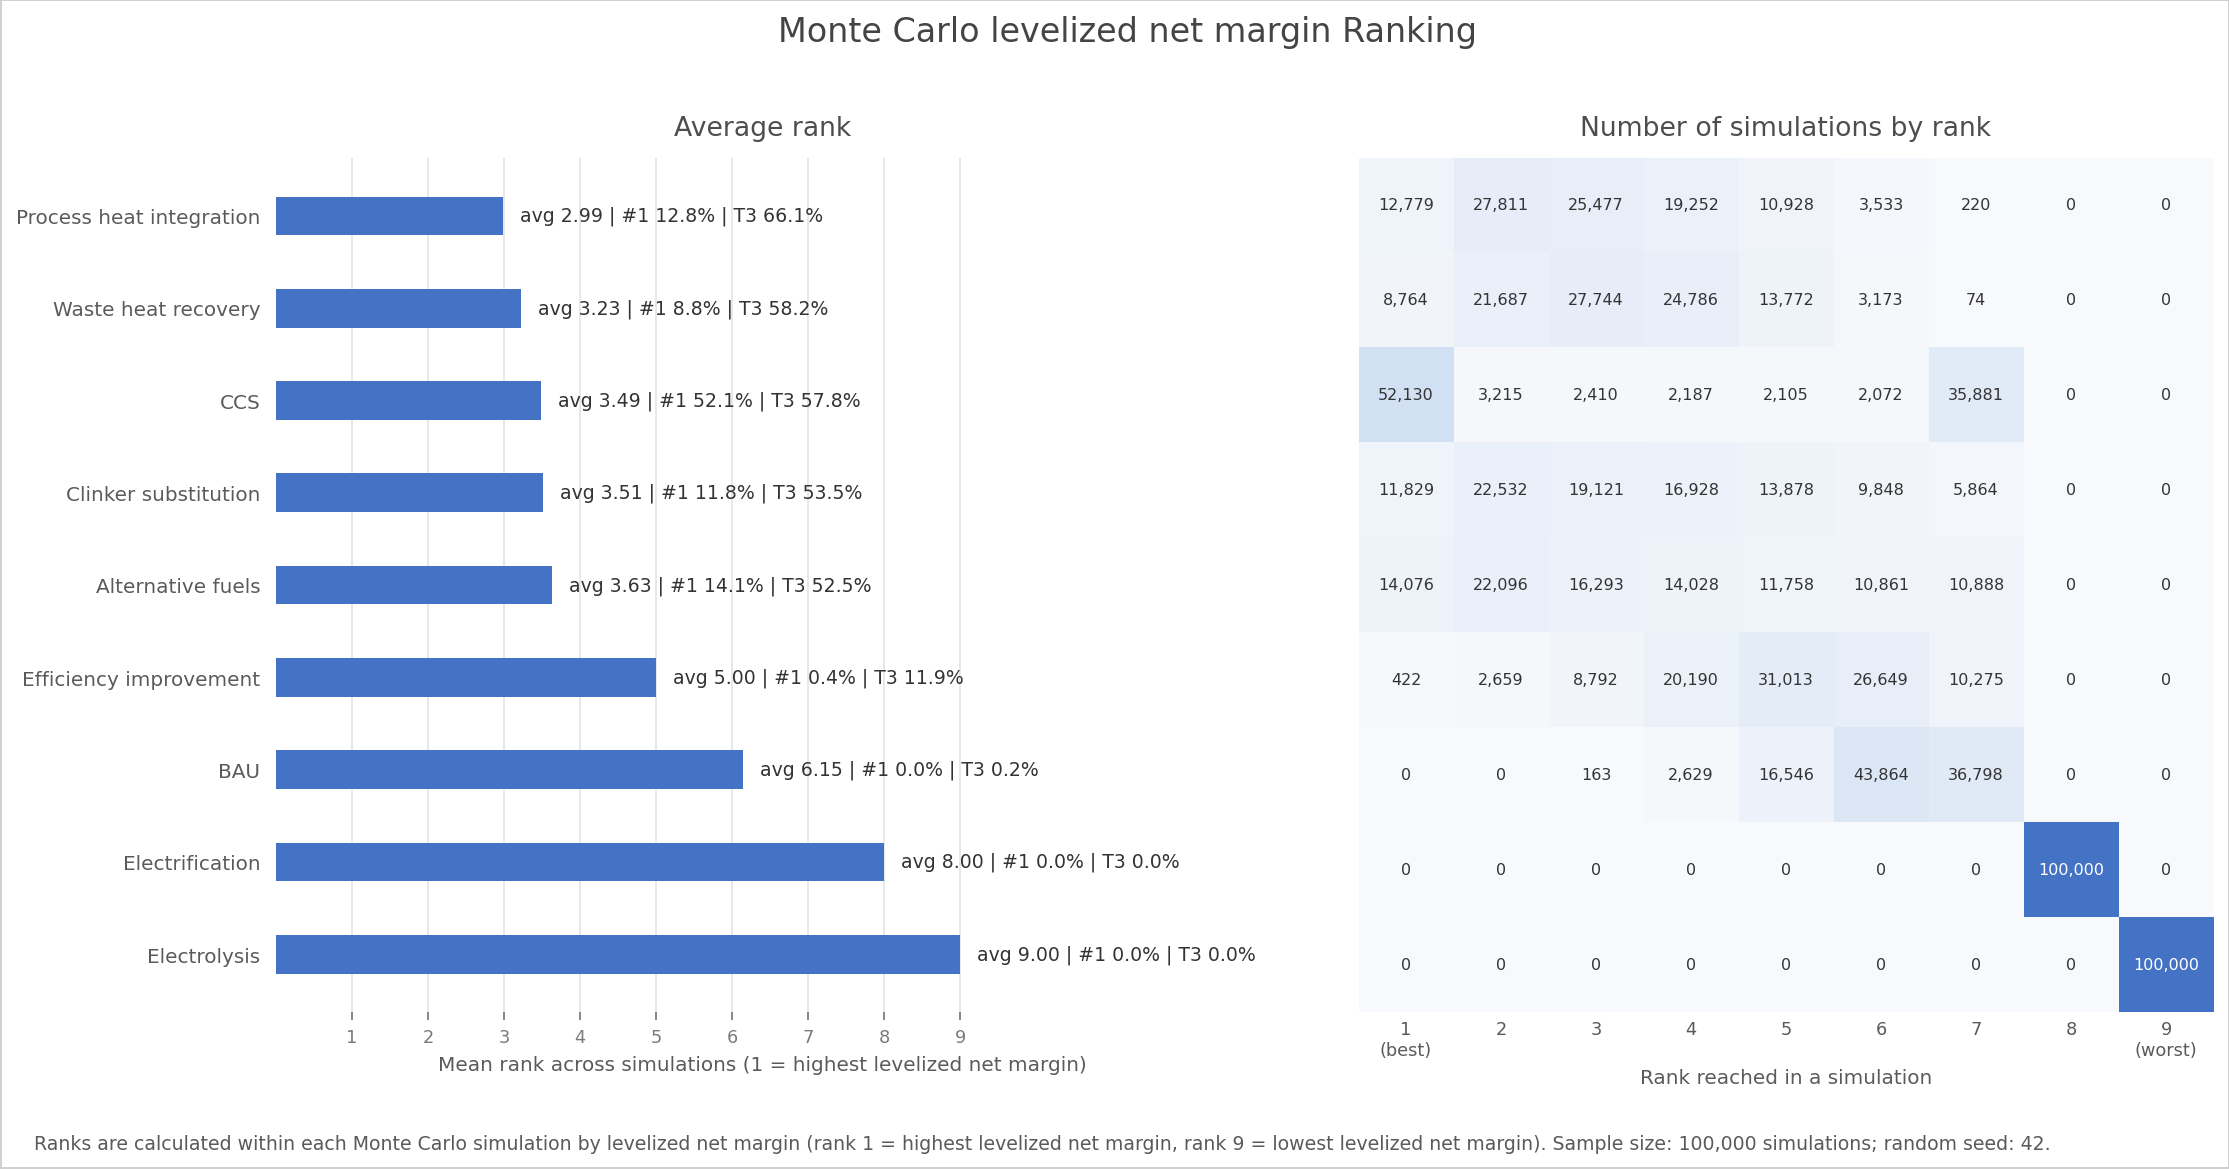

In [5]:
ranking_raw, ranking_summary = calculate_cement_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Cement",
    financial_metric=FINANCIAL_METRIC,
)

ranking_summary_for_plot = ranking_summary.assign(
    display_label=ranking_summary["technology"].map(CEMENT_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"])
)
rank_table = (
    ranking_summary_for_plot.rename(columns={"display_label": "Technology"})
    .loc[:, ["Technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_average_rank_bars(
    ranking_summary=ranking_summary_for_plot,
    output_path=None,
    title=f"Monte Carlo {METRIC_RANKING_LABEL} Ranking",
    metric_label=METRIC_RANKING_LABEL,
    random_seed=RANDOM_SEED,
)
plt.show()
